# STgram-MFN Colab Training Launcher

This notebook is the Colab entry point for the STgram-MFN / pretrained-checkpoint experiment. The real training logic lives in `pipeline/05_train_stgram.py` and evaluation lives in `pipeline/06_evaluate_stgram.py`, so the notebook stays small and the project remains reusable from scripts, GitHub, and Colab.

Use this notebook for GPU training. Do not run full training locally.

## 1. Enable GPU

In Colab, go to `Runtime > Change runtime type > T4 GPU`, then run the next cell.

In [13]:
import torch

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

PyTorch: 2.11.0+cu128
CUDA available: True
GPU device: Tesla T4


## 2. Clone The Repo

This checks out the active migration branch.

In [14]:
!git clone https://github.com/SARWAGYASHAH/Anomalous-Sound-Detection-using-Spectrograms.git
%cd Anomalous-Sound-Detection-using-Spectrograms
!git checkout migrate-to-keras
!git pull

Cloning into 'Anomalous-Sound-Detection-using-Spectrograms'...
remote: Enumerating objects: 394, done.
remote: Counting objects: 100% (394/394), done.
remote: Compressing objects: 100% (263/263), done.
remote: Total 394 (delta 174), reused 319 (delta 102), pack-reused 0 (from 0)
Receiving objects: 100% (394/394), 26.12 MiB | 25.74 MiB/s, done.
Resolving deltas: 100% (174/174), done.
/content/Anomalous-Sound-Detection-using-Spectrograms/Anomalous-Sound-Detection-using-Spectrograms
Branch 'migrate-to-keras' set up to track remote branch 'migrate-to-keras' from 'origin'.
Switched to a new branch 'migrate-to-keras'
Already up to date.


## 3. Install Dependencies

In [15]:
# Keep Colab's preinstalled GPU stacks intact.
!pip install -q -r requirements-colab.txt
!pip install -q -e . --no-deps

import joblib, librosa, sklearn
print('Dependencies ready')

  Preparing metadata (setup.py) ... done
Dependencies ready


## 4. Attach Data

The raw gearbox zip is stored on Google Drive and downloaded with `gdown`.

If the download cell fails, open the Drive file sharing settings and set access to `Anyone with the link`.

In [16]:
from pathlib import Path

DRIVE_ZIP_URL = 'https://drive.google.com/file/d/1p6TDo1GpTWHQzfHRcxs7NgXtG4-xVzqS/view?usp=drive_link'
ZIP_PATH = Path('Data/dev_data_gearbox.zip')
ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    !gdown --fuzzy "$DRIVE_ZIP_URL" -O Data/dev_data_gearbox.zip

print('Zip exists:', ZIP_PATH.exists())
print('Zip size MB:', round(ZIP_PATH.stat().st_size / (1024 * 1024), 2) if ZIP_PATH.exists() else 'missing')

Downloading...
From (original): https://drive.google.com/uc?id=1p6TDo1GpTWHQzfHRcxs7NgXtG4-xVzqS
From (redirected): https://drive.google.com/uc?id=1p6TDo1GpTWHQzfHRcxs7NgXtG4-xVzqS&confirm=t&uuid=315c7c21-18bf-4232-858e-dce55535e922
To: /content/Anomalous-Sound-Detection-using-Spectrograms/Anomalous-Sound-Detection-using-Spectrograms/Data/dev_data_gearbox.zip
100% 1.20G/1.20G [00:05<00:00, 212MB/s]
Zip exists: True
Zip size MB: 1144.64


In [17]:
!unzip -q -o Data/dev_data_gearbox.zip -d Data/
!ls Data
!find Data -maxdepth 4 -type d \( -name train -o -name source_test -o -name target_test \) | sort

dev_data_gearbox.zip  gearbox
Data/gearbox/source_test
Data/gearbox/target_test
Data/gearbox/train


## 5. Verify Raw Data

STgram-MFN trains directly from raw `.wav` files, so this notebook does not need the spectrogram preprocessing step used by the Keras autoencoder notebook.

In [20]:
from pathlib import Path

def find_split(split):
    candidates = [Path('Data/gearbox') / split]
    candidates += [path for path in Path('Data').rglob(split) if path.is_dir()]
    for path in candidates:
        if path.exists() and list(path.glob('*.wav')):
            return path
    raise FileNotFoundError(f'Could not find a raw WAV folder for {split}. Run the download/unzip cells again and check the Drive link permissions.')

for split in ['train', 'source_test', 'target_test']:
    path = find_split(split)
    files = list(path.glob('*.wav'))
    normal = sum('normal' in file.name.lower() for file in files)
    anomaly = sum('anomaly' in file.name.lower() for file in files)
    print(path, 'total=', len(files), 'normal=', normal, 'anomaly=', anomaly)

Data/gearbox/train total= 3026 normal= 3026 anomaly= 0
Data/gearbox/source_test total= 762 normal= 411 anomaly= 351
Data/gearbox/target_test total= 645 normal= 309 anomaly= 336


## 6. Optional Pretrained Checkpoint

Leave `PRETRAINED_CHECKPOINT` empty for the first run. Later, you can point it to a previous `best_model.pt` in Drive and optionally freeze the backbone for a lighter fine-tuning run.

In [21]:
PRETRAINED_CHECKPOINT = ''
FREEZE_BACKBONE = False

extra_args = ''
if PRETRAINED_CHECKPOINT:
    extra_args += f' --pretrained-checkpoint "{PRETRAINED_CHECKPOINT}"'
if FREEZE_BACKBONE:
    extra_args += ' --freeze-backbone'

print('Extra training args:', extra_args or '(none)')

Extra training args: (none)


## 7. Dry Run

This builds the raw-audio dataset/model and runs one forward pass. It does not train.

In [27]:
!python pipeline/05_train_stgram.py --config config/stgram_mfn.yaml --dry-run --batch-size 4 --num-workers 2 $extra_args

2026-05-28 11:55:44 | INFO     | train_stgram | Log file: artifacts/logs/run_20260528_115544.log
2026-05-28 11:55:44 | INFO     | train_stgram | ============================================================
2026-05-28 11:55:44 | INFO     | train_stgram | PIPELINE STAGE 5: Training (STgram-MFN)
2026-05-28 11:55:44 | INFO     | train_stgram | ============================================================
2026-05-28 11:55:44 | INFO     | train_stgram | PyTorch version: 2.11.0+cu128
2026-05-28 11:55:44 | INFO     | train_stgram | Device: cuda
2026-05-28 11:55:48 | INFO     | train_stgram | Training files: 3026
2026-05-28 11:55:48 | INFO     | train_stgram | Section labels: {'section_00': 0, 'section_01': 1, 'section_02': 2}
2026-05-28 11:55:48 | INFO     | train_stgram | Dry batch waveform: (4, 160000)
2026-05-28 11:55:48 | INFO     | train_stgram | Dry batch mel: (4, 128, 313)
2026-05-28 11:55:48 | INFO     | train_stgram | Dry batch logits: (4, 3)
2026-05-28 11:55:48 | INFO     | train_stgr

## 8. First Short Training Run

Start with a short run to verify Colab paths, GPU, model saving, GMM fitting, and graph generation.

In [19]:
!python pipeline/05_train_stgram.py --config config/stgram_mfn.yaml --epochs 3 --batch-size 32 --num-workers 2 $extra_args

2026-05-28 11:16:46 | INFO     | train_stgram | Log file: artifacts/logs/run_20260528_111646.log
2026-05-28 11:16:46 | INFO     | train_stgram | ============================================================
2026-05-28 11:16:46 | INFO     | train_stgram | PIPELINE STAGE 5: Training (STgram-MFN)
2026-05-28 11:16:46 | INFO     | train_stgram | ============================================================
2026-05-28 11:16:46 | INFO     | train_stgram | PyTorch version: 2.11.0+cu128
2026-05-28 11:16:46 | INFO     | train_stgram | Device: cuda
2026-05-28 11:16:52 | INFO     | train_stgram | Training files: 3026
2026-05-28 11:16:52 | INFO     | train_stgram | Section labels: {'section_00': 0, 'section_01': 1, 'section_02': 2}
2026-05-28 11:16:52 | INFO     | train_stgram | Dry batch waveform: (32, 160000)
2026-05-28 11:16:52 | INFO     | train_stgram | Dry batch mel: (32, 128, 313)
2026-05-28 11:16:52 | INFO     | train_stgram | Dry batch logits: (32, 3)
2026-05-28 11:16:52 | INFO     | train_s

## 9. Full Training Run

Run this after the short run succeeds. Every run creates a new versioned directory under `artifacts/models/stgram_mfn/`, so previous trained models are not overwritten.

In [22]:
!python pipeline/05_train_stgram.py --config config/stgram_mfn.yaml $extra_args

2026-05-28 16:30:42 | INFO     | train_stgram | Log file: artifacts/logs/run_20260528_163042.log
2026-05-28 16:30:42 | INFO     | train_stgram | ============================================================
2026-05-28 16:30:42 | INFO     | train_stgram | PIPELINE STAGE 5: Training (STgram-MFN)
2026-05-28 16:30:42 | INFO     | train_stgram | ============================================================
2026-05-28 16:30:42 | INFO     | train_stgram | PyTorch version: 2.11.0+cu128
2026-05-28 16:30:42 | INFO     | train_stgram | Device: cuda
2026-05-28 16:30:50 | INFO     | train_stgram | Training files: 3026
2026-05-28 16:30:50 | INFO     | train_stgram | Section labels: {'section_00': 0, 'section_01': 1, 'section_02': 2}
2026-05-28 16:30:50 | INFO     | train_stgram | Dry batch waveform: (32, 160000)
2026-05-28 16:30:50 | INFO     | train_stgram | Dry batch mel: (32, 128, 313)
2026-05-28 16:30:50 | INFO     | train_stgram | Dry batch logits: (32, 3)
2026-05-28 16:30:50 | INFO     | train_s

## 10. Evaluate Source And Target Test Sets

In [23]:
!python pipeline/06_evaluate_stgram.py --config config/stgram_mfn.yaml --split source_test --assets-dir docs/assets
!python pipeline/06_evaluate_stgram.py --config config/stgram_mfn.yaml --split target_test --assets-dir docs/assets

2026-05-28 16:41:56 | INFO     | evaluate_stgram | Log file: artifacts/logs/run_20260528_164156.log
2026-05-28 16:41:57 | INFO     | evaluate_stgram | ============================================================
2026-05-28 16:41:57 | INFO     | evaluate_stgram | PIPELINE STAGE 6: Evaluation (STgram-MFN)
2026-05-28 16:41:57 | INFO     | evaluate_stgram | ============================================================
2026-05-28 16:41:57 | INFO     | evaluate_stgram | Device: cuda
2026-05-28 16:41:57 | INFO     | evaluate_stgram | Artifact dir: artifacts/models/stgram_mfn/run_20260528_163050
2026-05-28 16:41:57 | INFO     | evaluate_stgram | Model: artifacts/models/stgram_mfn/run_20260528_163050/best_model.pt
2026-05-28 16:41:57 | INFO     | evaluate_stgram | GMM: artifacts/models/stgram_mfn/run_20260528_163050/gmm_per_section.joblib
2026-05-28 16:41:57 | INFO     | evaluate_stgram | Split: source_test
score: 100% 95/95 [00:55<00:00,  1.72it/s]
score: 100% 24/24 [00:14<00:00,  1.60it/s]
202

## 11. Inspect Metrics And Graphs

In [24]:
import json
from pathlib import Path

for split in ['source_test', 'target_test']:
    metrics_path = Path('artifacts/evaluation_stgram') / split / 'metrics.json'
    metrics = json.loads(metrics_path.read_text())
    print('\n' + split)
    print(json.dumps(metrics['metrics'], indent=2))


source_test
{
  "auc_roc": 0.573114008637123,
  "pauc": 0.508029853784752,
  "threshold": -305.6081480723665,
  "average_precision": 0.5216157159301539,
  "precision": 0.527027027027027,
  "recall": 0.1111111111111111,
  "f1": 0.18352941176470589,
  "true_positives": 39,
  "true_negatives": 376,
  "false_positives": 35,
  "false_negatives": 312
}

target_test
{
  "auc_roc": 0.5533498998304823,
  "pauc": 0.500166273288399,
  "threshold": -305.6081480723665,
  "average_precision": 0.550030895618335,
  "precision": 0.5068493150684932,
  "recall": 0.11011904761904762,
  "f1": 0.18092909535452323,
  "true_positives": 37,
  "true_negatives": 273,
  "false_positives": 36,
  "false_negatives": 299
}


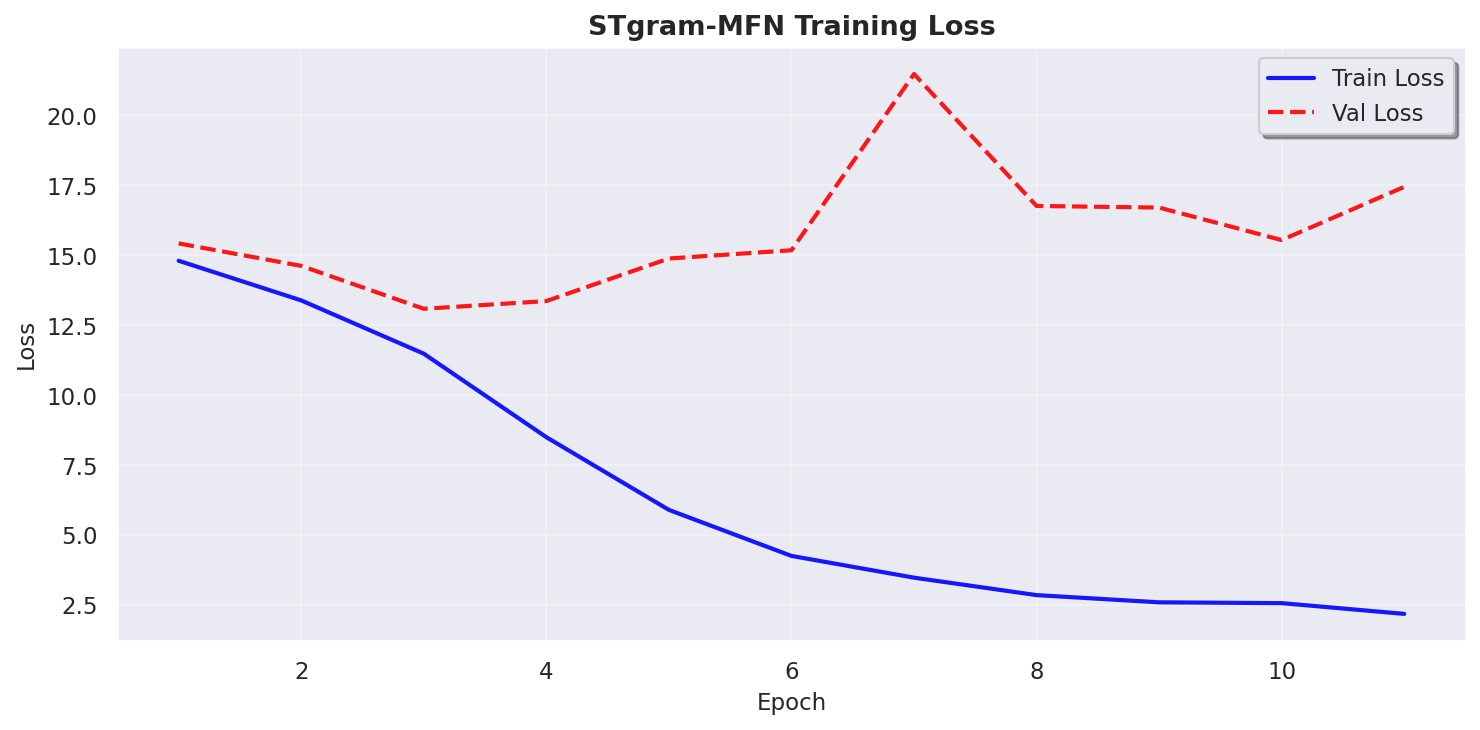

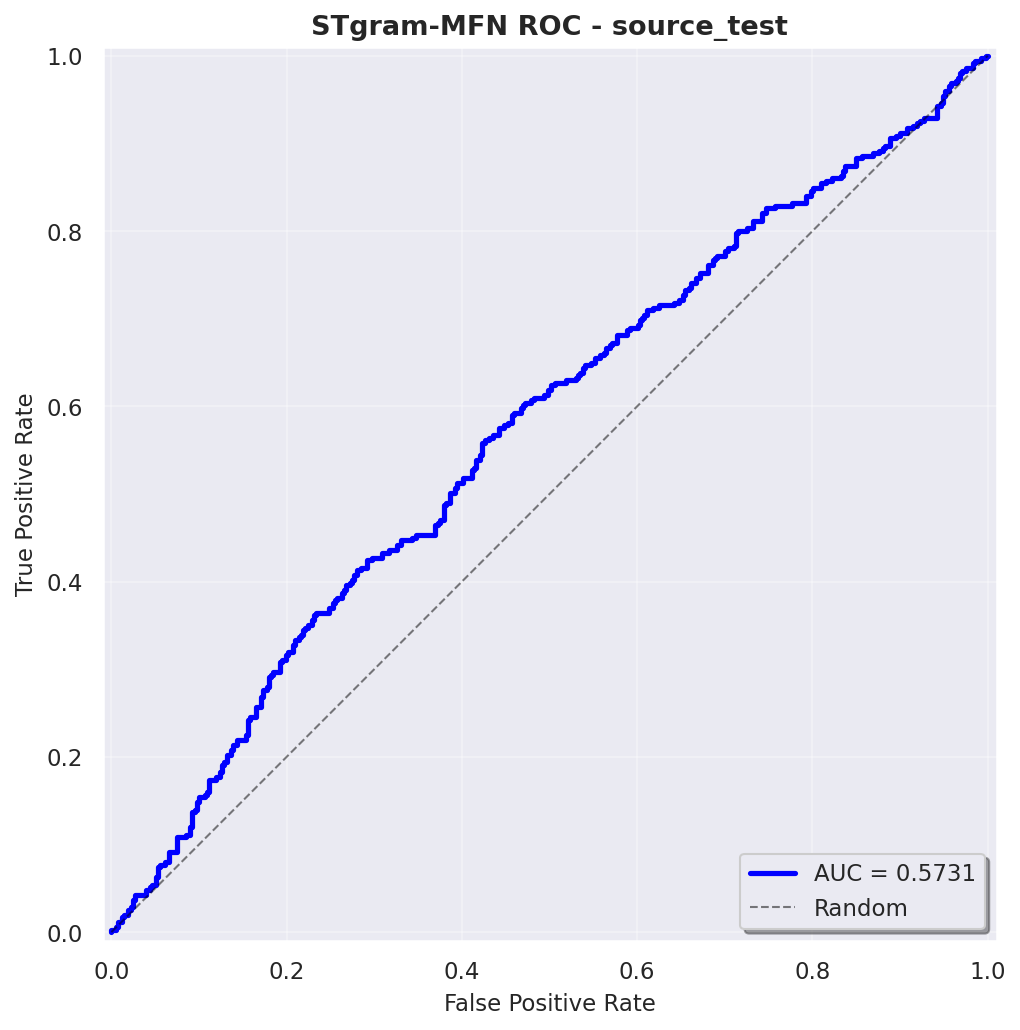

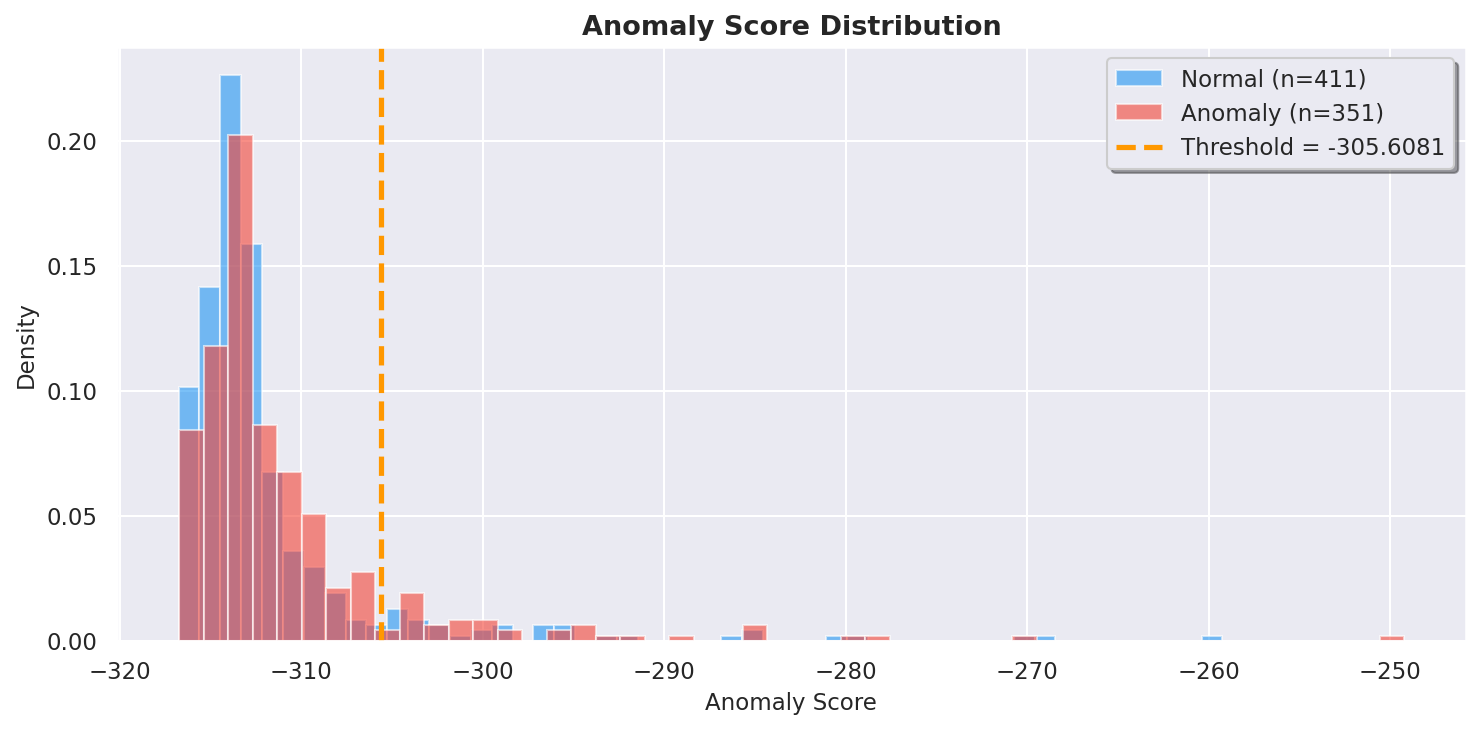

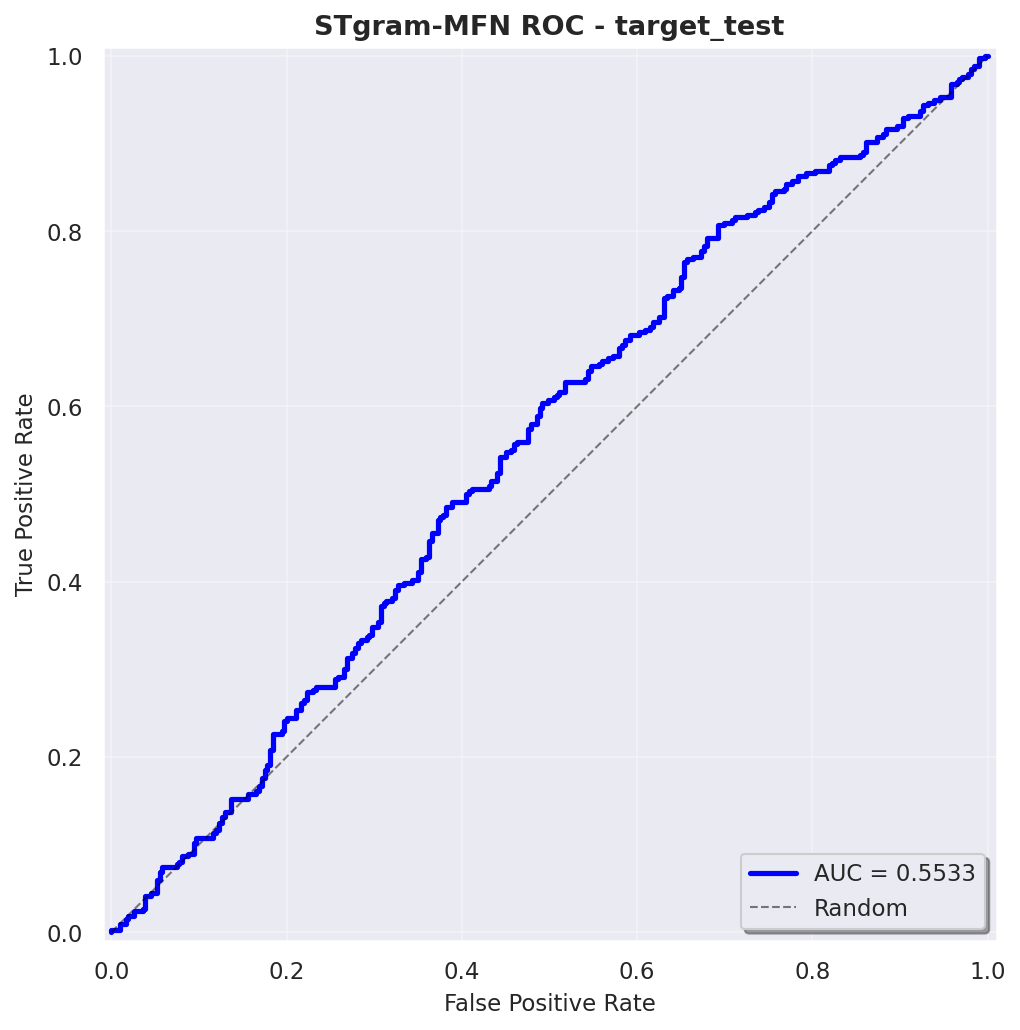

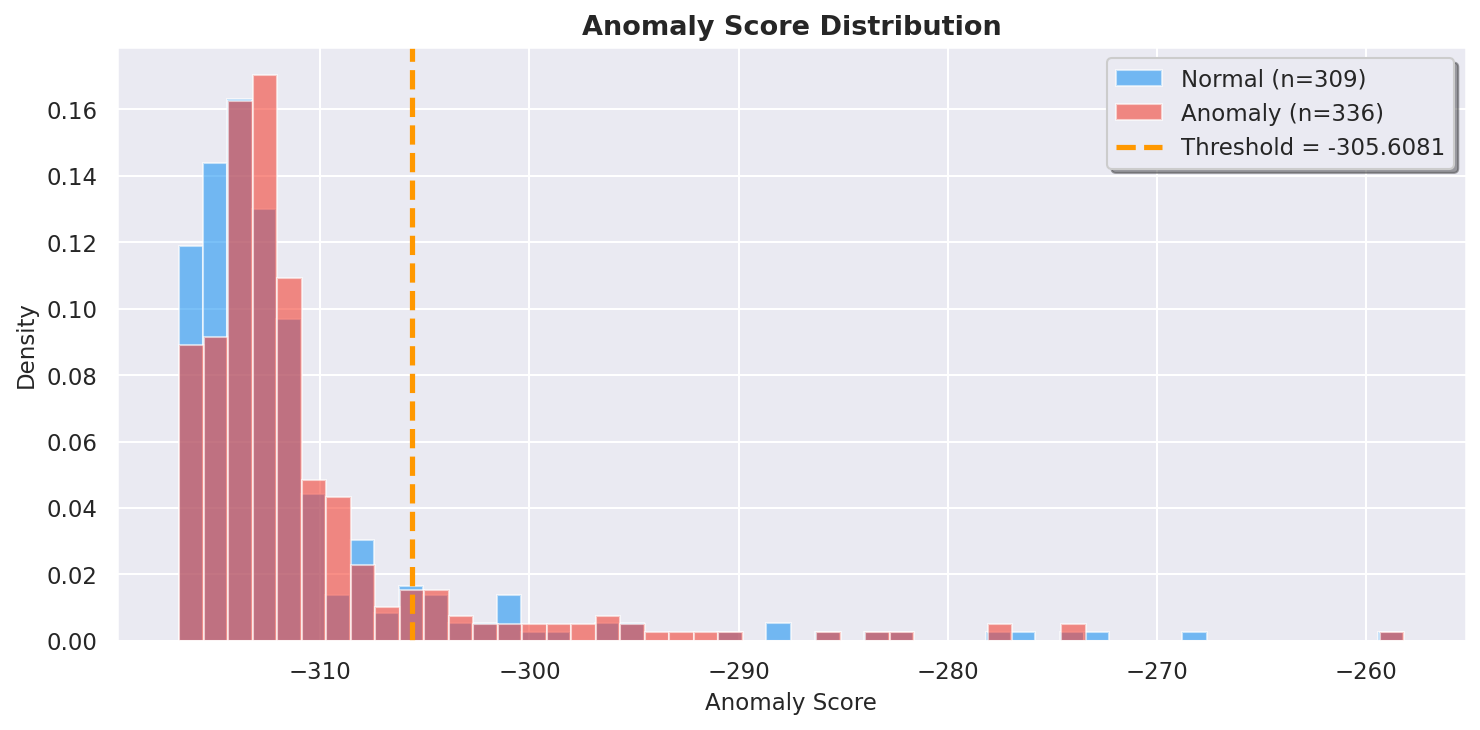

In [25]:
from IPython.display import Image, display
from pathlib import Path

latest_run = Path(Path('artifacts/models/stgram_mfn/latest.txt').read_text().strip())
display(Image(filename=str(latest_run / 'training_loss.png')))

for path in [
    Path('artifacts/evaluation_stgram/source_test/roc_curve.png'),
    Path('artifacts/evaluation_stgram/source_test/anomaly_score_distribution.png'),
    Path('artifacts/evaluation_stgram/target_test/roc_curve.png'),
    Path('artifacts/evaluation_stgram/target_test/anomaly_score_distribution.png'),
]:
    display(Image(filename=str(path)))

## 12. Save Artifacts To Drive

In [26]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/anomalous_sound_detection/stgram_mfn
!cp -r artifacts/models/stgram_mfn /content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/models
!cp -r artifacts/evaluation_stgram /content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/evaluation
!cp -r docs/assets /content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets
!find /content/drive/MyDrive/anomalous_sound_detection/stgram_mfn -maxdepth 3 -type f | sort | tail -80

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_anomaly_scores.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_combined_anomaly_scores.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_combined_roc_curve.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_latent_anomaly_scores.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_latent_roc_curve.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_roc_curve.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/assets/source_test_stgram_anomaly_scores.png
/content/drive/MyDrive/anomalous_sound_detection/stgram_mfn/docs_assets/asset